# Inflow & MOFA-Flex: Spatially-Resolved Cell-Cell Communication Programs

## Overview

This tutorial demonstrates how to integrate **inflow score** with **MOFA-Flex** to extract spatially-resolved, single-cell derived communication programs from mouse brain tissue. 

For a detailed walkthrough of the inflow score itself, please see our tutorial: [Inferring Cell–Cell Interactions at Single Cell Resolution](https://github.com/saezlab/liana-py/blob/main/docs/notebooks/inflow_score.ipynb).

For more information about [MOFA-Flex](https://www.biorxiv.org/content/10.1101/2025.11.03.686250v1), please visit their [documentation](https://mofaflex.readthedocs.io/stable/).

<img src="Inflow_Mofaflex_overview.png" width=1000 />

---

## Load Packages

```pip install mofaflex``` # Needed for spatially-aware MOFA

In [1]:
import os
import warnings

import anndata as ad
import mudata as md
import numpy as np
import pandas as pd

import liana as li
import mofaflex as mfl
import squidpy as sq

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import scanpy as sc
import plotnine as p9

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Load and Prep Data

To demonstrate the integration in practice, we reuse the same spatial transcriptomics dataset as the [inflow score tutorial](https://github.com/saezlab/liana-py/blob/main/docs/notebooks/inflow_score.ipynb): a MERFISH dataset from [*A molecularly defined and spatially resolved cell atlas of the whole mouse brain* (Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

In [113]:
file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

if os.path.exists(file_path):
    adata = sc.read(file_path)
else:
    adata = sc.read(
    file_path,
    backup_url=backup_url
)

In [114]:
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
adata.var_names = adata.var["gene_name"]

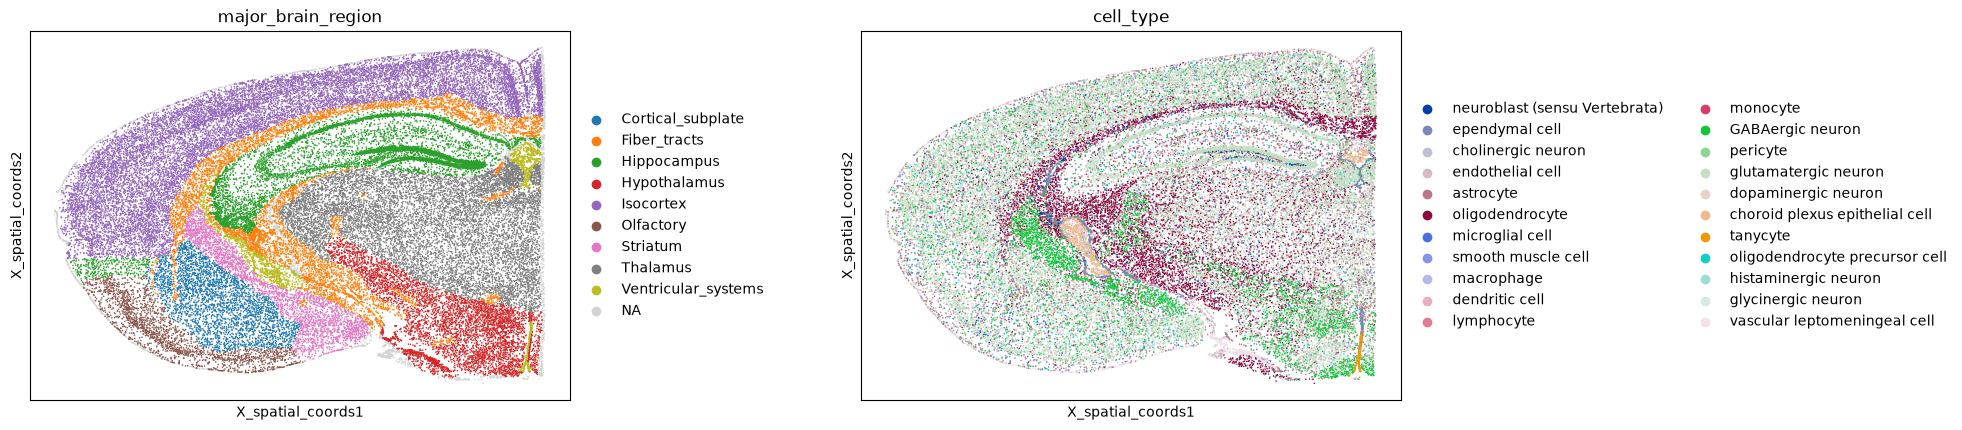

In [185]:
sc.pl.embedding(adata, basis="X_spatial_coords", color=["major_brain_region", "cell_type"], wspace=0.4, s=5)

## Basic Prep and QC

In [5]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

In [6]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Compute Inflow Score (Condensed Recap)

We briefly recompute the inflow score here, for a full walkthrough of bandwidth selection, spatial connectivity, and spatially variable gene (SVG) filtering, see the [inflow score tutorial](https://github.com/saezlab/liana-py/blob/main/docs/notebooks/inflow_score.ipynb).

Since this dataset is mouse, we go straight to the `mouseconsensus` resource.

In [7]:
li.ut.spatial_neighbors(adata=adata, bandwidth=30, spatial_key="X_spatial_coords")

sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
adata = adata[:, svgs]

resource = li.rs.select_resource('mouseconsensus')

lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource=resource,
                      use_raw=False)
lrdata.shape

/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(51539, 1713)

### Optional: filter to spatially variable LR interactions

In [8]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
lrdata = lrdata[:, svis]
lrdata.shape

(51539, 1408)

---
## From AnnData to MuData

We need to reshapes the inflow score AnnData into a MuData object, where each **sender cell type becomes a view**.

In [ ]:
from liana.multi import lrdata_to_mudata

mdata = lrdata_to_mudata(lrdata, min_features=80, obs_keys=["cell_type", "major_brain_region"])
mdata

/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1467: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1318: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


MuData object with n_obs × n_vars = 51539 × 629
  obs:	'cell_type', 'major_brain_region'
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
  7 modalities
    glutamatergic neuron:	51539 × 98
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
    GABAergic neuron:	51539 × 93
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
    microglial cell:	51539 × 82
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
    oligodendrocyte precursor cell:	51539 × 89
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
    astrocyte:	51539 × 94
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
    endothelial cell:	51539 × 85
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
    oligodendrocyte:	51539 × 88
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'

---
## Training MOFA-Flex

MOFA-Flex extends the standard MOFA framework with a **Gaussian Process (GP) factor prior**: instead of treating cells as exchangeable, the GP prior encodes spatial proximity, so nearby cells in tissue are expected to have similar factor values. This makes factors spatially interpretable rather than just statistically optimal.

Here we pair the GP factor prior with **Horseshoe weight prior** to promotes sparsity in the features loading matrix, so each factor is driven by a small, coherent set of features.

Training can take significant time and memory depending on dataset size and `max_epochs`; for large datasets, consider running this as a background job or on a compute cluster outside the notebook rather than interactively.

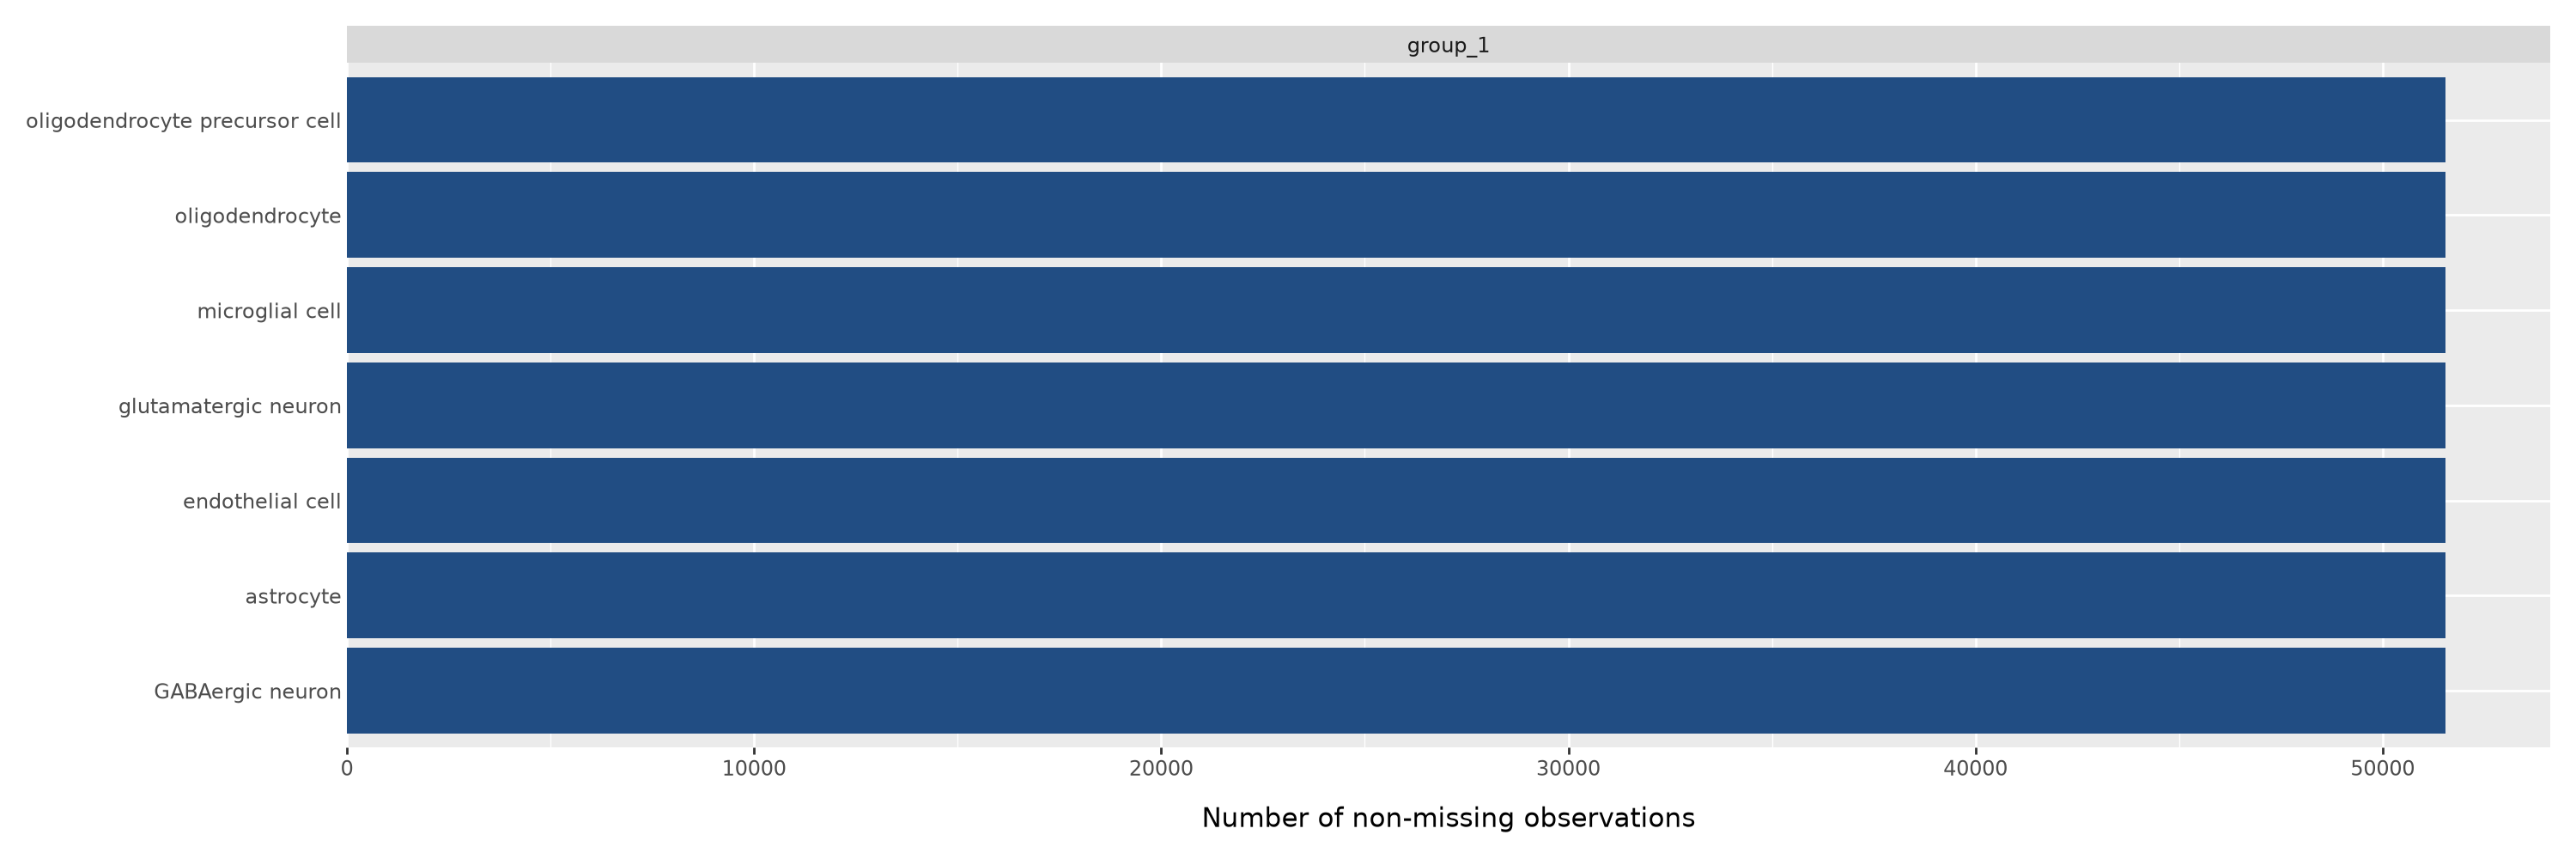

/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1467: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1318: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1467: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities

  0%|                                                                                                         …

Guessed max_plate_nesting = 2
Training converged after 69 epochs.
/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1467: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_mofa_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1318: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
Saving results to models/inflow_mofaflex_mouse_brain.hdf5...
models/inflow_mofaflex_mouse_brain.hdf5 already exists, overwriting
/g/

In [64]:
os.makedirs("models", exist_ok=True)

model = mfl.terms.MofaFlex(
    n_factors=10,
    factor_prior=mfl.priors.GaussianProcess(
        covariates_mkey="X_spatial_coords",
        independent_lengthscales=True,
    ),
    weight_prior=mfl.priors.Horseshoe(),
)

model.fit(
    mdata,
    batch_size=2048,
    n_particles=1,
    lr=0.01,
    max_epochs=1000,
    save_path="models/inflow_mofaflex_mouse_brain.hdf5",
    early_stopper_patience=20,
    device="cuda",
)

---
## Model Quality Checks

Before interpreting factors biologically, we run two diagnostic checks:

1. **Factor correlation**: correlated factor pairs may encode the same signal, indicating the model could be simplified or that a biological program was split across multiple factors.
2. **Variance explained**: quantifies how much of the data variance each factor accounts for, per modality. Factors with near-zero R² are noise and will be removed in the next step.

If you trained the model in a separate process (as suggested above for large datasets), reload it here. If you just ran the training cell above in this notebook, `model` is already in memory and this step is not needed.

In [94]:
# Optional: reload a previously trained model
model = mfl.MOFAFLEX.load("models/inflow_mofaflex_mouse_brain.hdf5")

### Latent Factor Correlation

Each factor captures an independent biological signal. Highly correlated factors (|r| > 0.6) suggest redundancy.

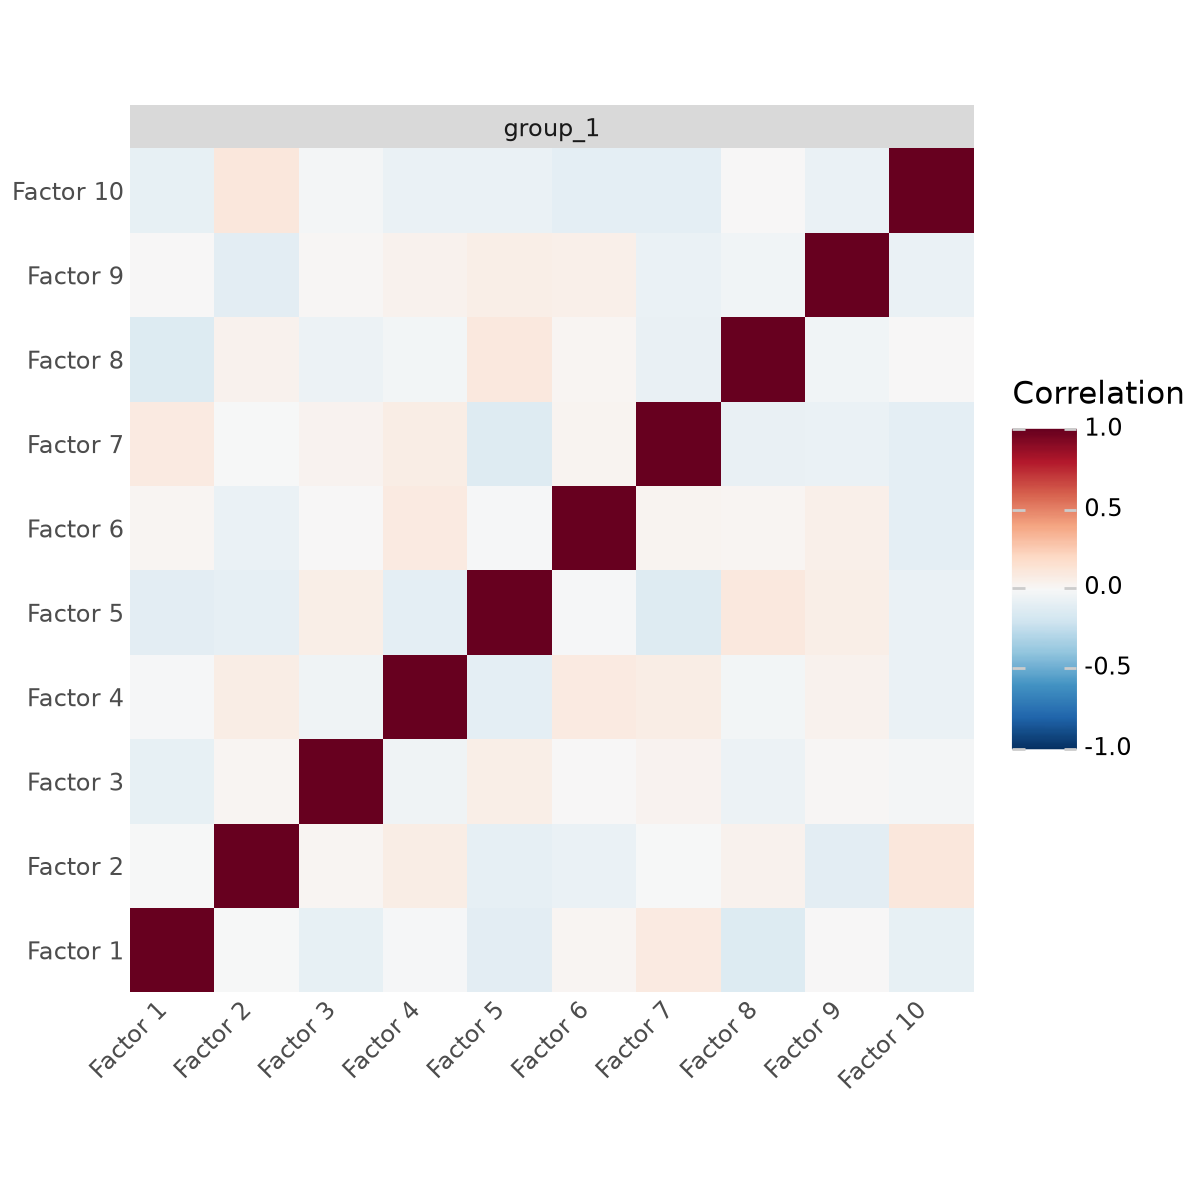

In [95]:
# Check for redundant factors: highly correlated factors may capture the same signal
mfl.pl.factor_correlation(model, figsize=(6, 6))

### Variance Explained per Modality

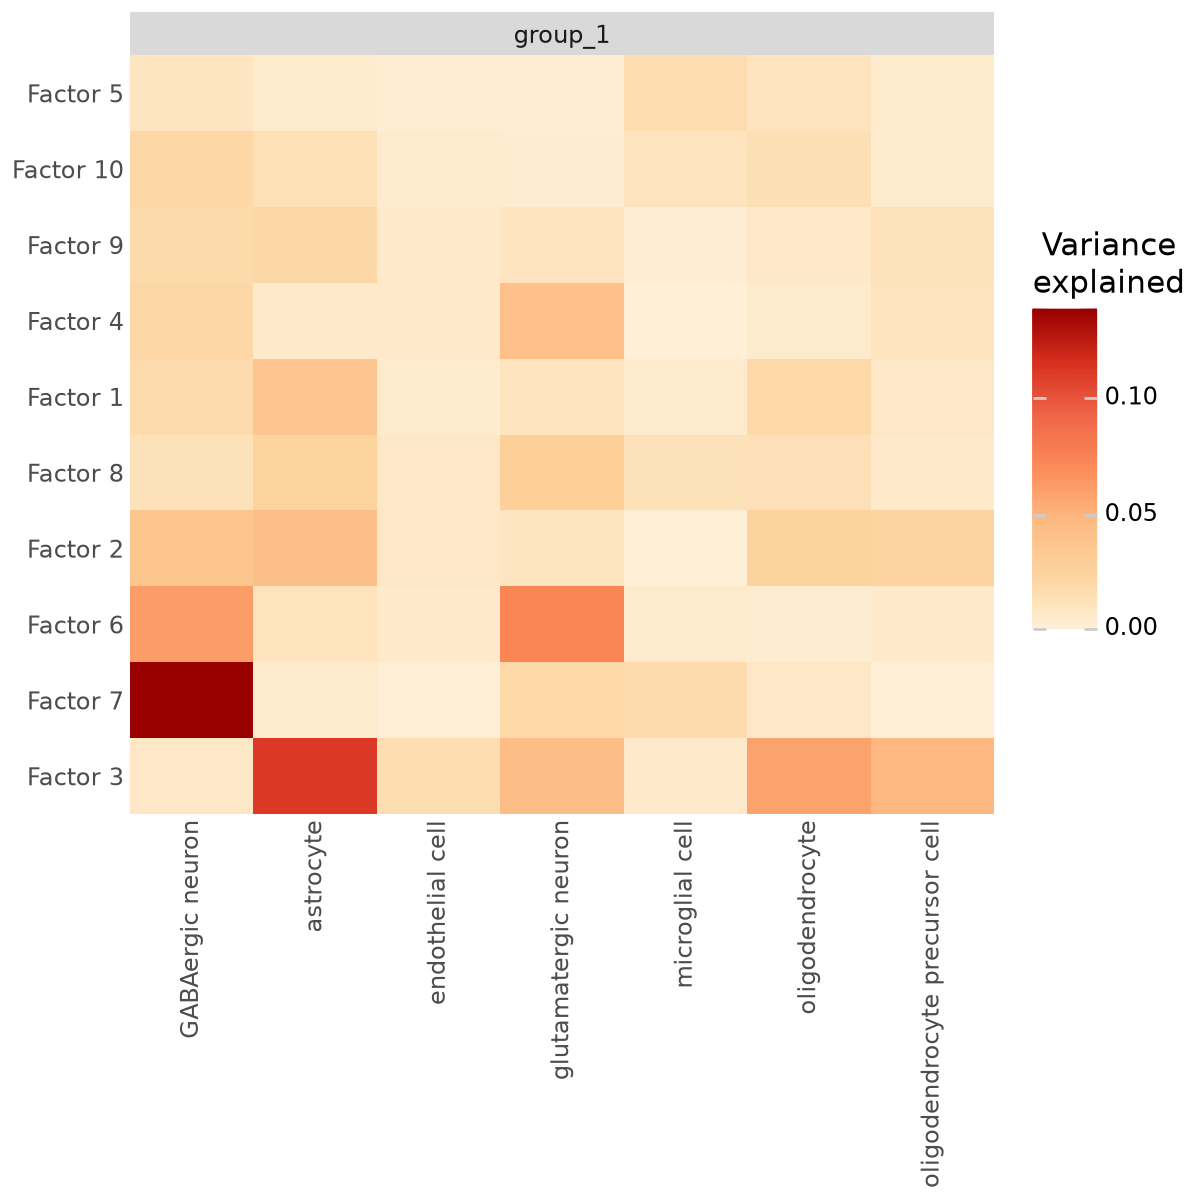

In [96]:
# How much variance does each factor explain?
# Helps identify which factors are biologically meaningful vs noise
mfl.pl.variance_explained(model, figsize=(6, 6))

---
## Selecting Informative Factors

Not all factors are equally informative. We keep a factor only if it clears a minimum R² floor in at least one modality (the standard definition of an "active"/non-noise factor), then among those, rank by total R² (summed across modalities) and keep the smallest subset that cumulatively explains ≥ 99% of the remaining explained variance.

In [ ]:
r2_df = model.get_r2(type="term", term=None)  # columns: group, view, component, R2
active = r2_df.groupby("component")["R2"].max()
active = active[active >= 0.02].index
active

In [99]:
total_per_factor = (
    r2_df[r2_df["component"].isin(active)]
    .groupby("component")["R2"]
    .sum()
    .sort_values(ascending=False)
)
total_per_factor

component
Factor 3     0.291629
Factor 7     0.190582
Factor 6     0.165845
Factor 2     0.144779
Factor 8     0.101250
Factor 1     0.099324
Factor 4     0.089654
Factor 10    0.070319
Name: R2, dtype: float64

In [100]:
n_keep = (total_per_factor.cumsum() / total_per_factor.sum() < 0.99).sum() + 1
total_per_factor.iloc[: int(n_keep)].index

Index(['Factor 3', 'Factor 7', 'Factor 6', 'Factor 2', 'Factor 8', 'Factor 1',
       'Factor 4', 'Factor 10'],
      dtype='object', name='component')

In [101]:
# Extract cell x factor matrix, keeping only the informative factors
# get_factors() returns dict[str, pd.DataFrame] (samples x factors), not AnnData
factors_df = model.get_factors()["group_1"]
factor_adata = ad.AnnData(factors_df)
factor_adata = factor_adata[:, total_per_factor.iloc[: int(n_keep)].index]
factor_adata

View of AnnData object with n_obs × n_vars = 51539 × 8

In [102]:
# Transfer spatial coordinates and metadata needed for downstream plotting/classification
factor_adata.obsm["spatial"] = adata.obsm["X_spatial_coords"].copy()

shared_obs = adata.obs_names.intersection(factor_adata.obs_names)
cols_to_copy = ["cell_type", "major_brain_region"]
factor_adata.obs.loc[shared_obs, cols_to_copy] = adata.obs.loc[shared_obs, cols_to_copy]

factors = factor_adata.var_names.tolist()

---
## Exploring Factors: Feature Weights and Spatial Activity

Each MOFA-Flex factor has two complementary representations:

- **Feature weights** (loadings): which LR-pairs drive the factor. Larger absolute weights indicate a stronger association between that feature and the factor.
- **Factor scores**: the per-cell value of the factor. Since the GP prior was used, these scores should vary smoothly across the tissue section.

### Top Feature Weights per Factor

The plot below shows the 5 features (LR pairs) with the largest absolute weight for each factor. Features appearing in multiple factors may represent shared biological themes.

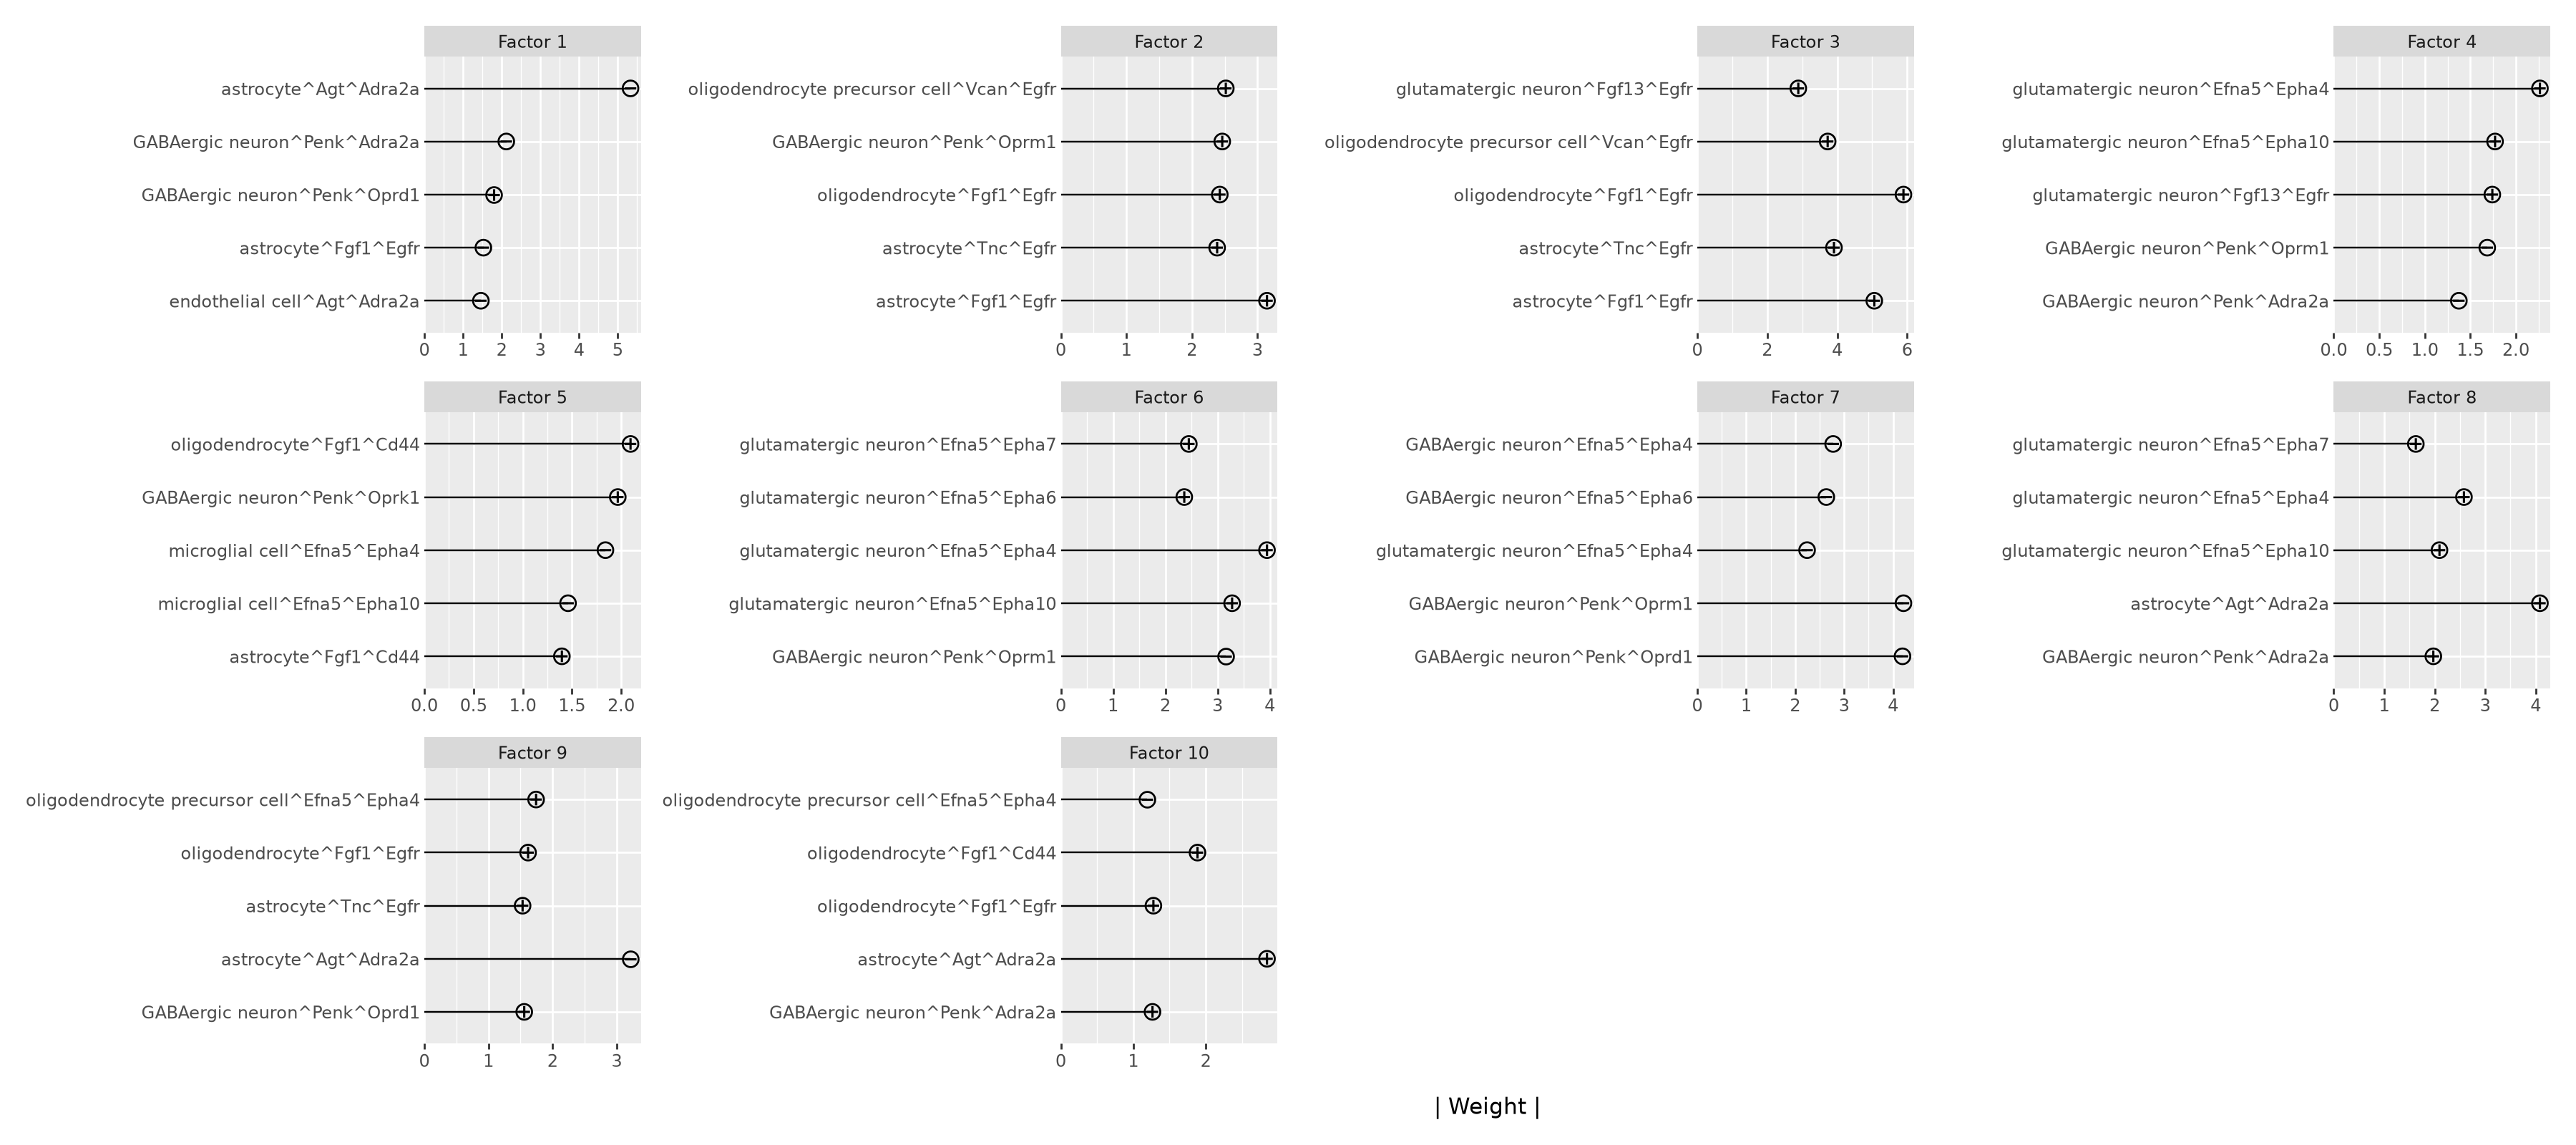

In [103]:
# For each factor, show the 5 features with the largest absolute weight.
# High-weight features are the molecular signals most strongly associated with that factor.
mfl.pl.top_weights(model, n_features=5, factors=None, figsize=(18, 8), nrow=None, ncol=None)

### Spatial Factor Activity

We now visualise each factor's score directly on the tissue.

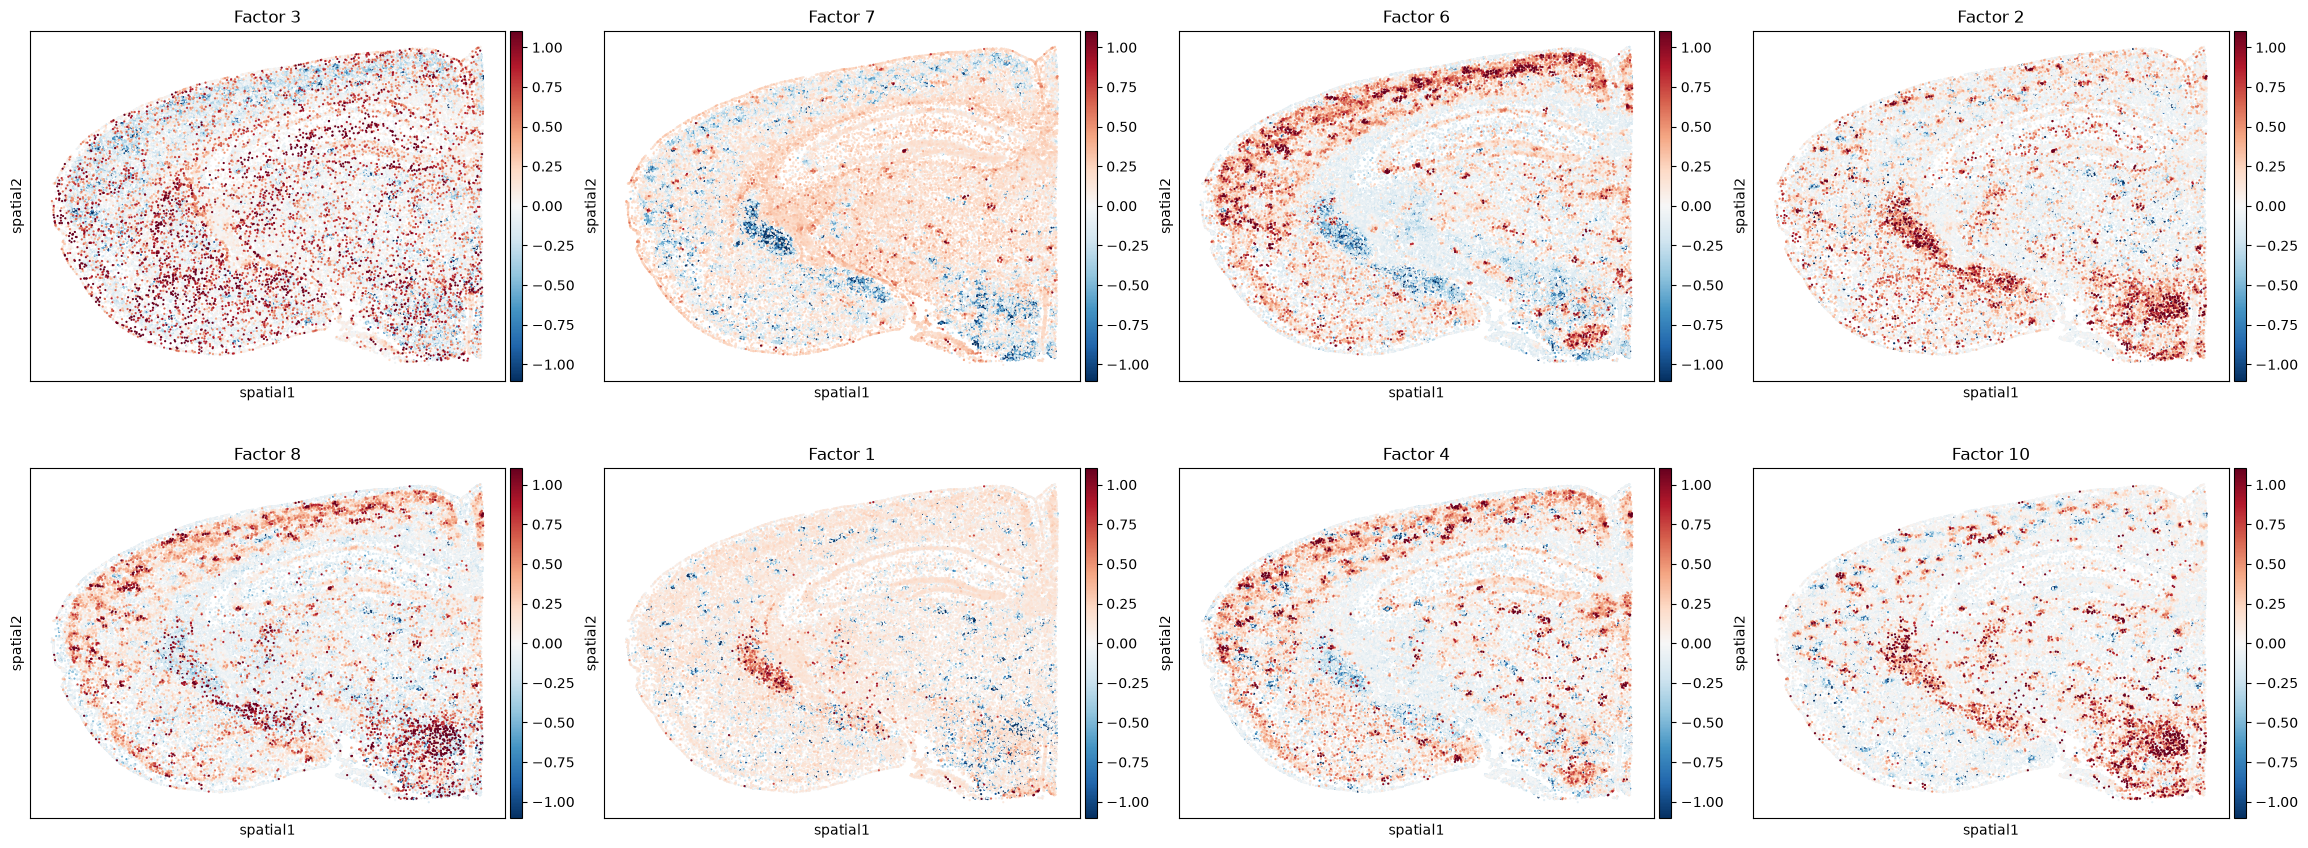

In [104]:
# For better visualization, we use a diverging colormap and set the color limits to be symmetric around zero.
vals = np.hstack([factor_adata[:, f].X.flatten() for f in factors])
# avoid outliers (better for color scaling)
p_low, p_high = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
absmax = max(abs(p_low), abs(p_high))

# make symmetric around 0
norm = colors.TwoSlopeNorm(vcenter=0, vmin=-absmax, vmax=absmax)

sc.pl.embedding(
    factor_adata,
    basis="spatial",
    color=factors,
    cmap="RdBu_r",
    norm=norm,
    s=10,
    ncols=4,
    wspace=0.1,
    show=True
)

---
## Cell Clustering in Factor Space

We build a k-nearest-neighbour (k-NN) graph directly on the factor matrix. This means cells are grouped by their communication program, rather than by raw inflow score similarity.

In [105]:
# Build a k-NN graph in factor space
sc.pp.neighbors(factor_adata, use_rep='X')

In [ ]:
# Embed the factor-space k-NN graph in 2D for visualization
sc.tl.umap(factor_adata, neighbors_key='neighbors')

In [181]:
# Cluster cells by communication program (low resolution -> few, coarse clusters)
sc.tl.leiden(factor_adata, resolution=0.1, flavor="igraph", n_iterations=2)

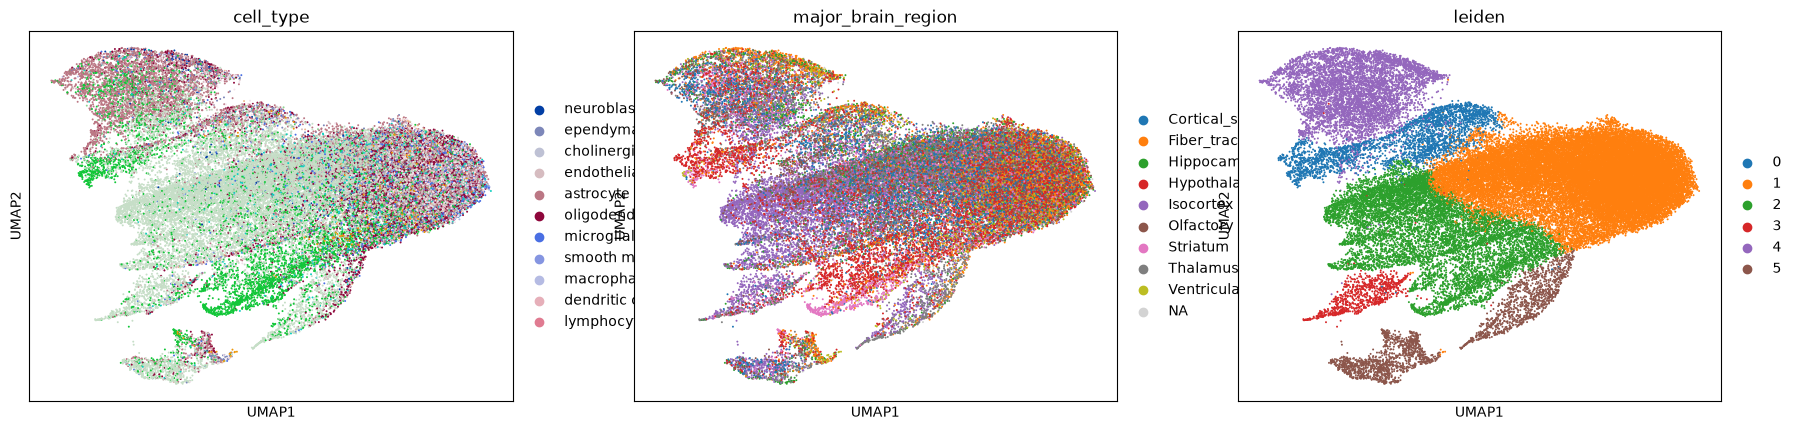

In [182]:
# Compare unsupervised Leiden clusters against known annotations
sc.pl.umap(
    factor_adata,
    color=["cell_type", "major_brain_region", "leiden"],
    size=8,
)

Overlay each factor's score on the same UMAP to see which factors drive which clusters

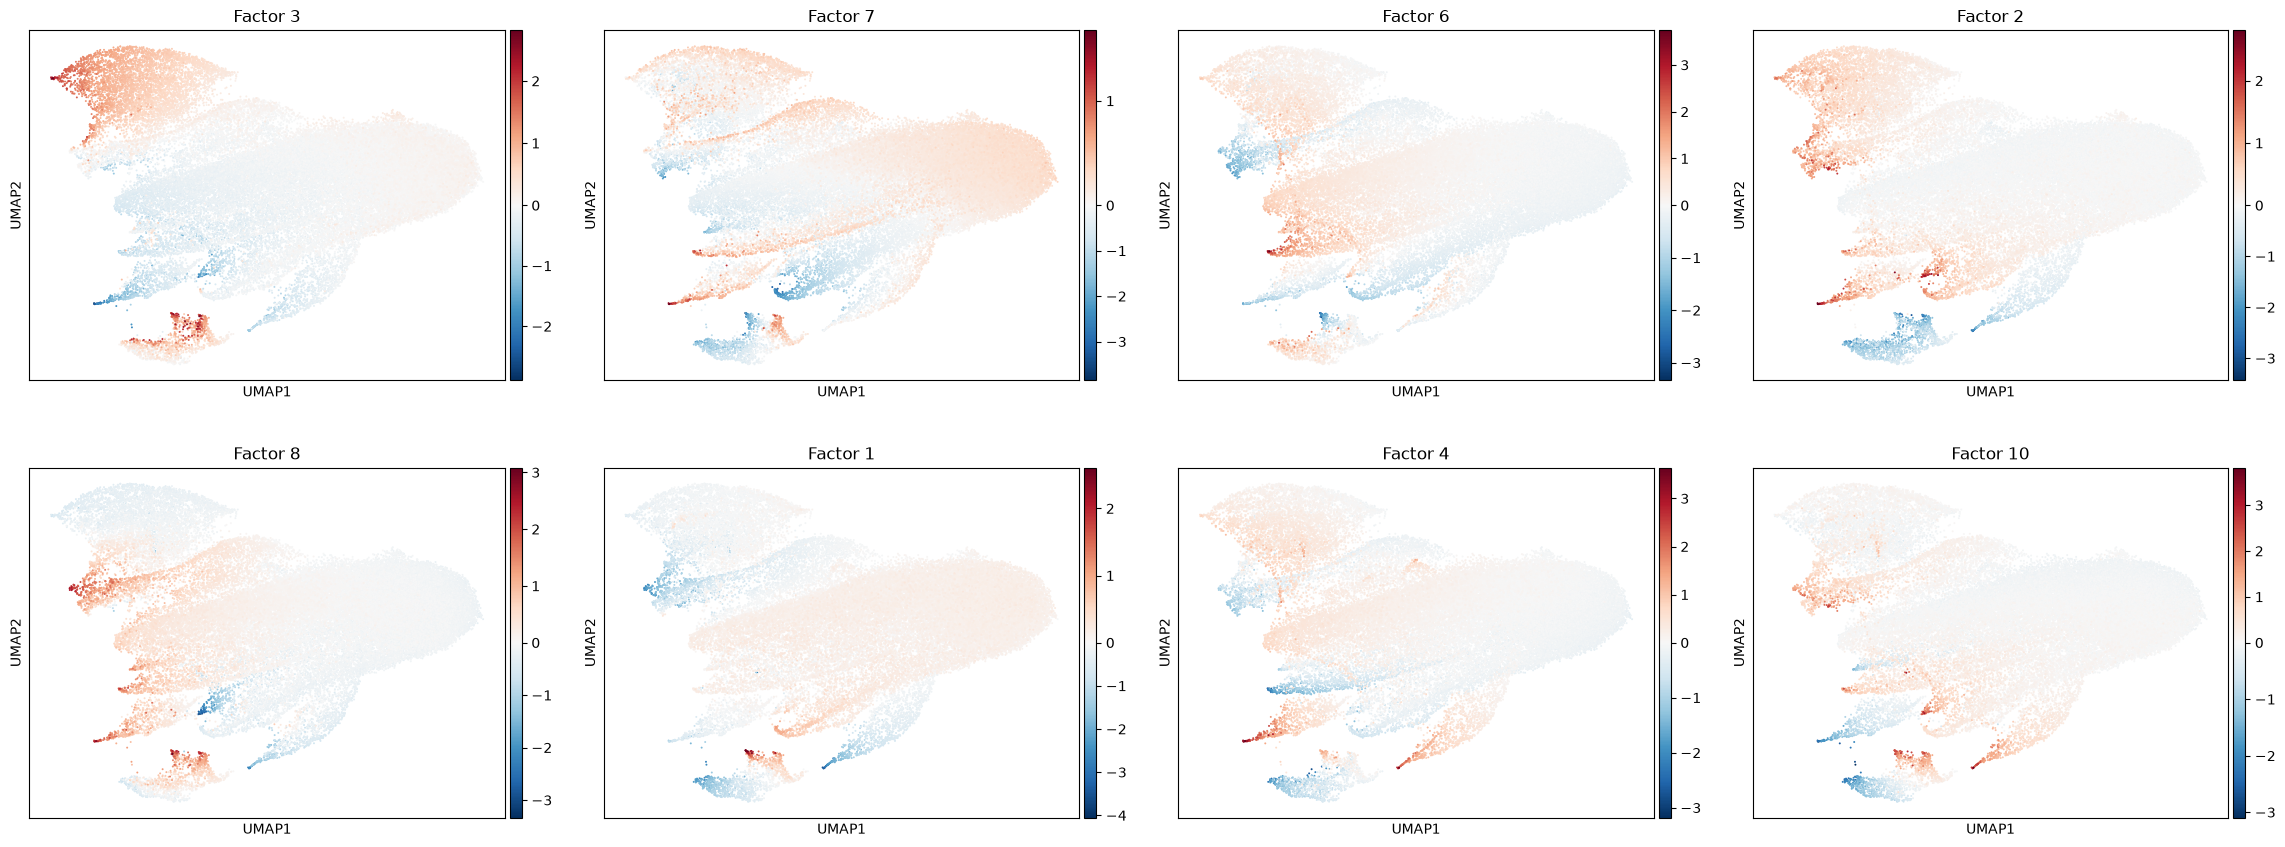

In [ ]:
sc.pl.umap(
    factor_adata,
    color=factors,           # factor scores as color
    cmap="RdBu_r",
    vcenter=0,
    size=8,
    ncols=4,
    wspace=0.1,
)

Check whether the Leiden clusters form spatially coherent regions in tissue

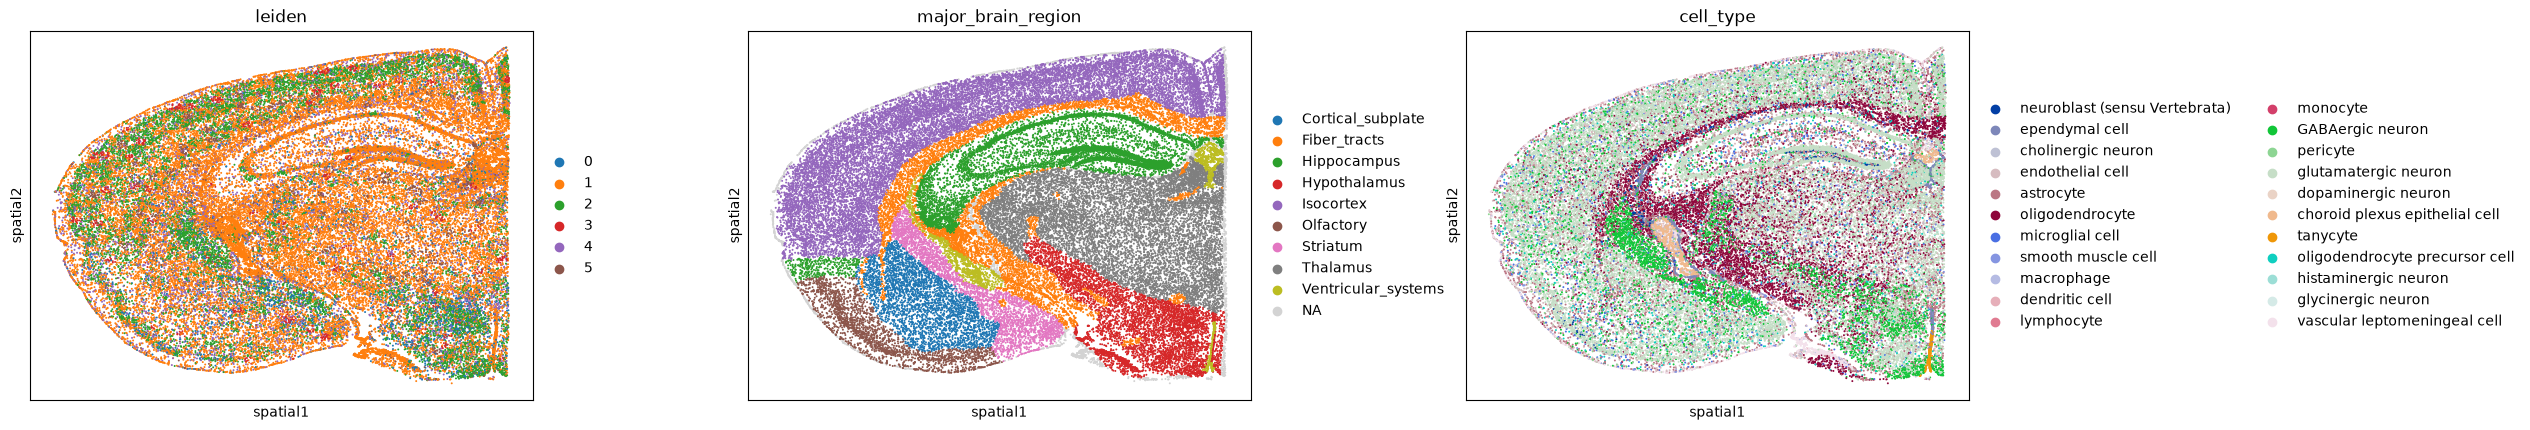

In [ ]:
sc.pl.embedding(
    factor_adata,
    basis="spatial",
    color=["leiden", "major_brain_region",  "cell_type"],
    s=8,
    wspace=0.3,
    show=True
)

One thing to notice is what cluster 3 and 5 are capturing 

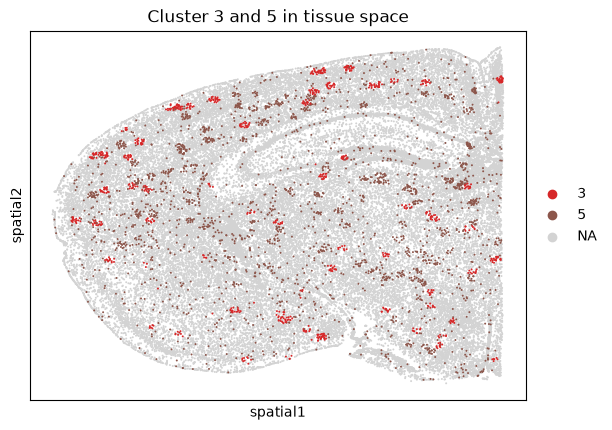

In [186]:
sc.pl.embedding(
    factor_adata,
    basis="spatial",
    color="leiden",
    groups=["5", "3"],       # highlight only cluster 3; everything else -> grey ("NA" color)
    s=8,
    title="Cluster 3 and 5 in tissue space",
    show=True
)

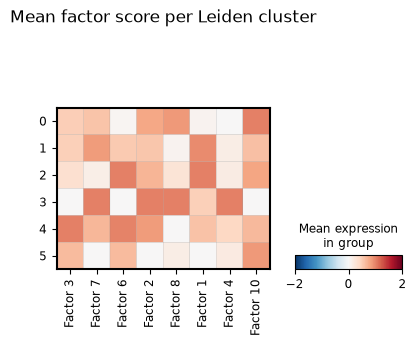

In [189]:
# Summarize which factors define each cluster's communication profile
sc.pl.matrixplot(
    factor_adata,
    var_names=factors,
    groupby="leiden",
    cmap="RdBu_r",
    vmin=-2, vmax=2,
    standard_scale="var",    # z-score per factor so all factors are comparable
    title="Mean factor score per Leiden cluster"
)

From the above plot, we find that cluster 3 and 5 capture islands with opposite CCC patterens.
We can check what cell types are main receeiver of these opposite signals.

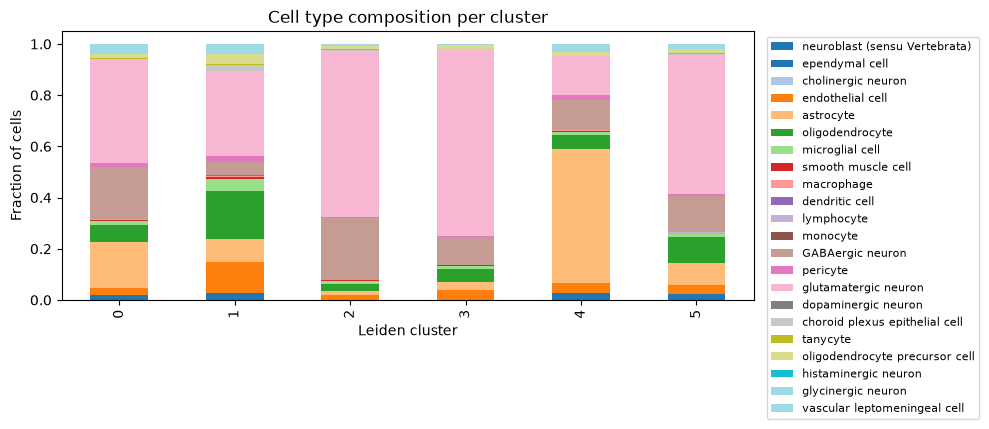

In [ ]:
# For each cluster, get the fraction of cells belonging to each cell type
comp = (
    factor_adata.obs
    .groupby(["leiden", "cell_type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)   # row-normalise to fraction
)

comp.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="tab20")
plt.ylabel("Fraction of cells")
plt.xlabel("Leiden cluster")
plt.title("Cell type composition per cluster")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The breakdowns below confirm this at the numbers level: clusters 3 and 5 are both overwhelmingly glutamatergic neurons in Isocortex/Thalamus, the same receiver population, in the same tissue regions. Since composition can't explain the split, the difference has to live in *which factor* (and therefore which sender + LR axis) is active in each cluster. We check that next.

In [ ]:
clusters = ["3", "5"]
tables = {}
for cl in clusters:
    sub = factor_adata.obs.loc[factor_adata.obs.leiden == cl]
    tables[cl] = pd.crosstab(sub["major_brain_region"], sub["cell_type"], normalize="all")

# align both tables to the same region/cell-type axes so panels are directly comparable
all_regions = sorted(set(tables["3"].index) | set(tables["5"].index))
all_types = sorted(set(tables["3"].columns) | set(tables["5"].columns))
for cl in clusters:
    tables[cl] = tables[cl].reindex(index=all_regions, columns=all_types, fill_value=0)

vmax = max(t.values.max() for t in tables.values())  # shared color scale across both panels

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

for ax, cl in zip(axes, clusters):
    sns.heatmap(
        tables[cl], cmap="Blues", annot=True, fmt=".1%",
        vmin=0, vmax=vmax, ax=ax,
        cbar=(cl == clusters[-1]),
        cbar_ax=cbar_ax if cl == clusters[-1] else None,
        cbar_kws={"label": "Fraction of cluster's cells"} if cl == clusters[-1] else None,
    )
    ax.set_title(f"Cluster {cl}")
    ax.set_xlabel("Cell type")
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

axes[0].set_ylabel("Major brain region")
fig.suptitle("Cluster 3 vs 5: near-identical receiver composition", y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### Which factors and which senders separate cluster 3 from cluster 5?

Factor loadings are organized by sender view (each feature is `sender_cell_type^ligand^receptor`), so ranking factors by how differently they score between cluster 3 and cluster 5, then inspecting each factor's top-weighted features, tells us both *which communication program* and *who is sending it*.

In [191]:
# z-score each factor across all cells so clusters are comparable
factor_z = factor_adata.to_df()
factor_z = (factor_z - factor_z.mean()) / factor_z.std()

cluster_means = factor_z.groupby(factor_adata.obs["leiden"], observed=True).mean()

# difference in mean factor activity: cluster 3 vs cluster 5
diff = (cluster_means.loc["3"] - cluster_means.loc["5"]).sort_values()
diff


Factor 10   -2.655270
Factor 3    -2.434154
Factor 6    -1.170127
Factor 1     1.028797
Factor 7     1.722164
Factor 8     1.865874
Factor 4     2.660187
Factor 2     4.256512
dtype: float32

In [192]:
top_factor = diff.index[-1]     # highest in cluster 3 relative to cluster 5
bottom_factor = diff.index[0]   # lowest in cluster 3 relative to cluster 5 (most suppressed there)
print(top_factor, bottom_factor)

Factor 2 Factor 10


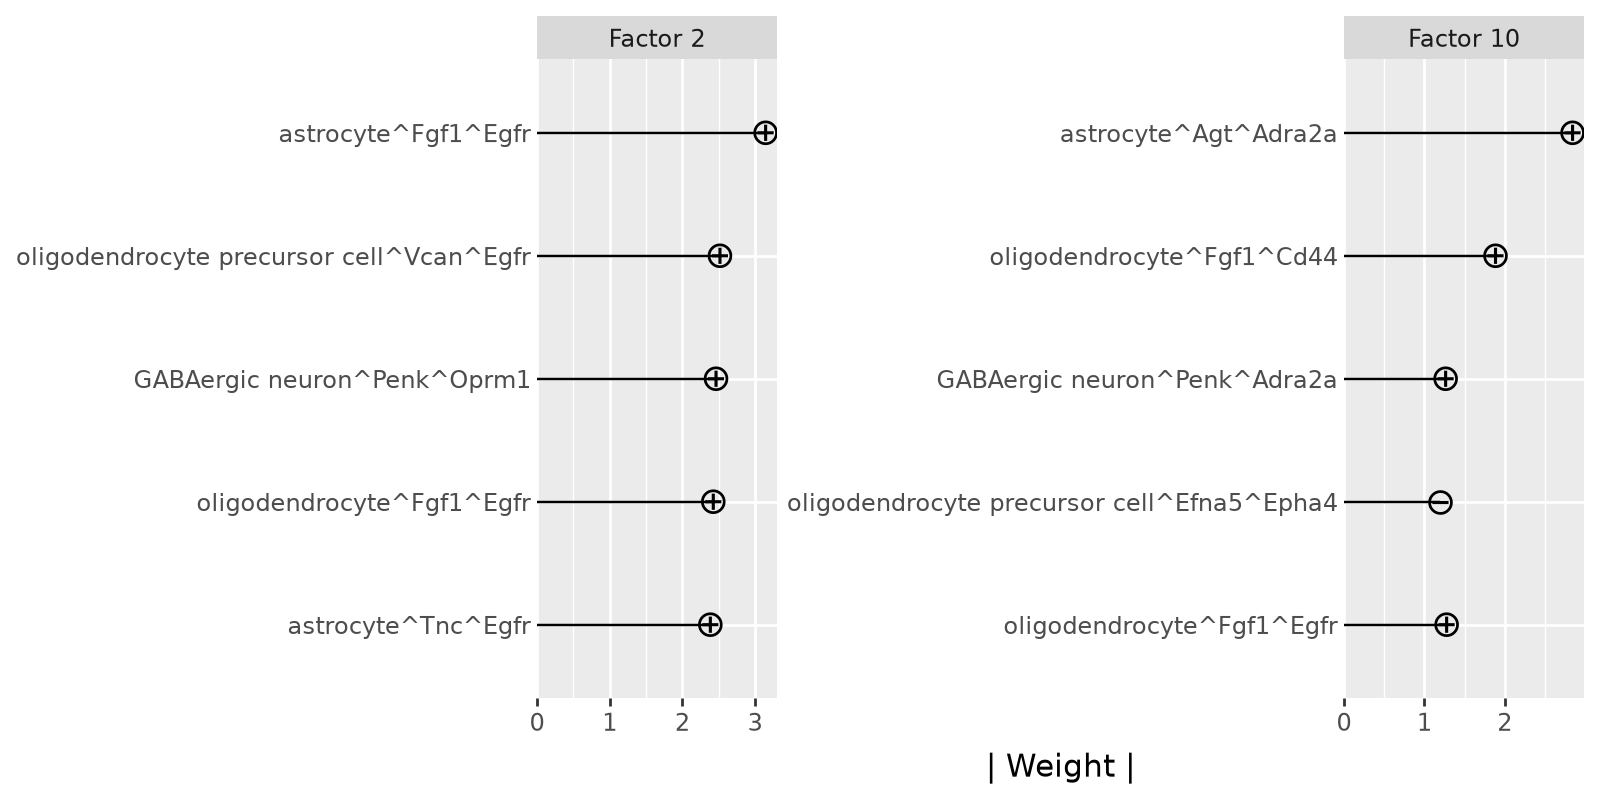

In [193]:
mfl.pl.top_weights(model, n_features=5, factors=[top_factor, bottom_factor], figsize=(8, 4))

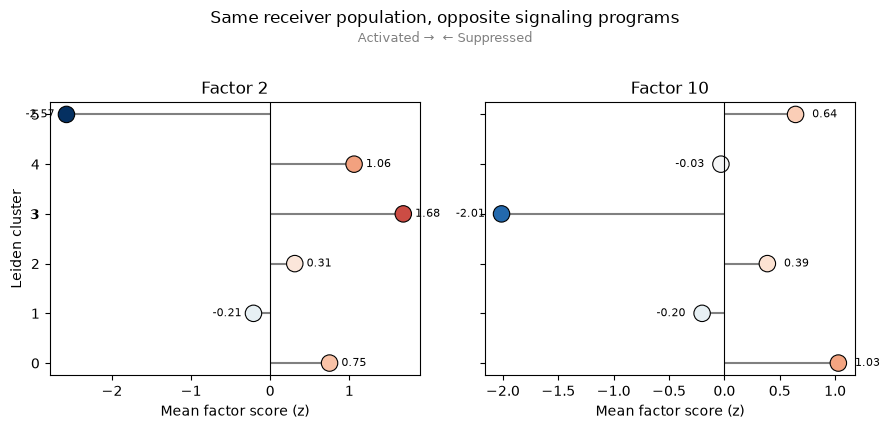

In [195]:
# Diverging summary: is each factor activated (+) or suppressed (-) per cluster?
focus_factors = [top_factor, bottom_factor]
order = cluster_means.index.tolist()
y_pos = np.arange(len(order))  # numeric positions avoid matplotlib's categorical-unit warning on numeric-looking strings

absmax = cluster_means[focus_factors].abs().max().max()
norm = colors.TwoSlopeNorm(vcenter=0, vmin=-absmax, vmax=absmax)
cmap = plt.get_cmap("RdBu_r")

fig, axes = plt.subplots(1, len(focus_factors), figsize=(9, 4), sharey=True)

for ax, factor in zip(axes, focus_factors):
    vals = cluster_means.loc[order, factor]
    ax.hlines(y_pos, 0, vals, color="grey", linewidth=1.5, zorder=1)
    ax.scatter(vals, y_pos, c=vals, cmap=cmap, norm=norm, s=140,
               edgecolor="black", linewidth=0.8, zorder=2)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(factor)
    ax.set_xlabel("Mean factor score (z)")
    for y, v in zip(y_pos, vals):
        ax.text(v + (0.15 if v >= 0 else -0.15), y, f"{v:.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(order)
axes[0].set_ylabel("Leiden cluster")

# highlight the cluster you're telling the story about
axes[0].get_yticklabels()[order.index("3")].set_fontweight("bold")

fig.text(0.5, 0.98, "Activated →  ← Suppressed", ha="center", fontsize=9, color="grey")
fig.suptitle("Same receiver population, opposite signaling programs", y=1.06)
plt.tight_layout()
plt.show()

---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>